In [10]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np

from iris_webcam import (
    LEFT_EYE,
    LEFT_IRIS,
    MODEL_PATH,
    RIGHT_EYE,
    RIGHT_IRIS,
    draw_landmarks,
    draw_pupil_position_text,
)

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode


def create_writer(output_path, fps, frame_width, frame_height):
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (frame_width, frame_height))
    if not writer.isOpened():
        raise RuntimeError(f"Failed to open output video for writing: {output_path}")
    return writer


def process_video(
    video_path,
    output_path=None,
    display=False,
    max_frames=None,
    num_faces=1,
    verbose=True,
):
    """Run iris tracking on a video and optionally save/display output.

    Args:
        video_path: Input video path.
        output_path: Optional output path for annotated video.
        display: Show preview window when True.
        max_frames: Process at most this many frames for quick exploration.
        num_faces: Number of faces to track.
        verbose: Print summary logs when True.
    """
    video_path = Path(video_path)
    output_path = Path(output_path) if output_path else None

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30.0

    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = create_writer(output_path, fps, frame_width, frame_height) if output_path else None

    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=VisionRunningMode.VIDEO,
        output_face_blendshapes=False,
        num_faces=num_faces,
    )

    last_timestamp_ms = -1
    frame_index = 0
    frames_with_face = 0

    try:
        with FaceLandmarker.create_from_options(options) as landmarker:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

                timestamp_ms = int(cap.get(cv2.CAP_PROP_POS_MSEC))
                if timestamp_ms <= 0:
                    timestamp_ms = int(frame_index * 1000 / fps)
                if timestamp_ms <= last_timestamp_ms:
                    timestamp_ms = last_timestamp_ms + 1
                last_timestamp_ms = timestamp_ms

                result = landmarker.detect_for_video(mp_image, timestamp_ms)

                if result and result.face_landmarks:
                    draw_landmarks(frame, result.face_landmarks[0])
                    draw_pupil_position_text(frame, result.face_landmarks[0])
                    frames_with_face += 1

                if writer is not None:
                    writer.write(frame)

                if display:
                    cv2.imshow("Iris Tracking (ESC to quit)", frame)
                    key = cv2.waitKey(1)
                    if key == 27:
                        break

                frame_index += 1
                if max_frames is not None and frame_index >= max_frames:
                    break
    finally:
        cap.release()
        if writer is not None:
            writer.release()
        cv2.destroyAllWindows()

    summary = {
        "input": str(video_path),
        "output": str(output_path) if output_path else None,
        "frames_processed": frame_index,
        "frames_with_face": frames_with_face,
        "fps": fps,
    }

    if verbose:
        print(summary)

    return summary


def _landmarks_to_pixels(landmarks, indices, frame_width, frame_height):
    pts = np.array(
        [[landmarks[i].x * frame_width, landmarks[i].y * frame_height] for i in indices],
        dtype=np.float32,
    )
    return pts


def _eye_crop_with_overlay(frame_bgr, landmarks, eye_indices, iris_indices, margin_ratio=0.28):
    h, w = frame_bgr.shape[:2]
    eye_pts = _landmarks_to_pixels(landmarks, eye_indices, w, h)
    iris_pts = _landmarks_to_pixels(landmarks, iris_indices, w, h)
    all_pts = np.vstack([eye_pts, iris_pts])

    min_xy = all_pts.min(axis=0)
    max_xy = all_pts.max(axis=0)
    box_size = max_xy - min_xy
    margin = np.maximum(box_size * margin_ratio, 8.0)

    x0 = int(max(0, np.floor(min_xy[0] - margin[0])))
    y0 = int(max(0, np.floor(min_xy[1] - margin[1])))
    x1 = int(min(w, np.ceil(max_xy[0] + margin[0])))
    y1 = int(min(h, np.ceil(max_xy[1] + margin[1])))

    if x1 <= x0 or y1 <= y0:
        return None

    crop = frame_bgr[y0:y1, x0:x1].copy()
    eye_crop_pts = (eye_pts - np.array([x0, y0], dtype=np.float32)).astype(np.int32)
    iris_crop_pts = (iris_pts - np.array([x0, y0], dtype=np.float32)).astype(np.int32)

    cv2.polylines(crop, [eye_crop_pts], isClosed=True, color=(0, 255, 255), thickness=1)
    for p in iris_crop_pts:
        cv2.circle(crop, tuple(p), 2, (0, 255, 0), -1)

    return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)


def _fit_crop_to_panel(crop_rgb, panel_width, panel_height):
    panel = np.zeros((panel_height, panel_width, 3), dtype=np.uint8)
    if crop_rgb is None or crop_rgb.size == 0:
        return panel

    crop_h, crop_w = crop_rgb.shape[:2]
    scale = min(panel_width / crop_w, panel_height / crop_h)
    resized = cv2.resize(
        crop_rgb,
        (max(1, int(round(crop_w * scale))), max(1, int(round(crop_h * scale)))),
        interpolation=cv2.INTER_LINEAR,
    )

    offset_y = (panel_height - resized.shape[0]) // 2
    offset_x = (panel_width - resized.shape[1]) // 2
    panel[offset_y : offset_y + resized.shape[0], offset_x : offset_x + resized.shape[1]] = resized
    return panel


def _compose_eye_crop_frame(left_crop, right_crop, frame_index, detected, panel_size=(320, 200)):
    panel_width, panel_height = panel_size
    gap = 16
    header_height = 44

    left_panel = _fit_crop_to_panel(left_crop, panel_width, panel_height)
    right_panel = _fit_crop_to_panel(right_crop, panel_width, panel_height)
    canvas = np.zeros((header_height + panel_height, panel_width * 2 + gap, 3), dtype=np.uint8)

    canvas[header_height:, :panel_width] = left_panel
    canvas[header_height:, panel_width + gap :] = right_panel

    cv2.putText(canvas, f"Frame {frame_index}", (14, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)
    status_text = "Face detected" if detected else "No face detected"
    status_color = (80, 220, 120) if detected else (80, 80, 255)
    cv2.putText(canvas, status_text, (220, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2)
    cv2.putText(canvas, "Left Eye", (14, header_height - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 255), 2)
    cv2.putText(
        canvas,
        "Right Eye",
        (panel_width + gap + 14, header_height - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (0, 255, 255),
        2,
    )

    if not detected:
        cv2.putText(
            canvas,
            "No detections",
            (panel_width // 2 - 72, header_height + panel_height // 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
        )
        cv2.putText(
            canvas,
            "No detections",
            (panel_width + gap + panel_width // 2 - 72, header_height + panel_height // 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2,
        )

    return cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR)


def export_eye_crops_video(
    video_path,
    output_path,
    max_frames=None,
    num_faces=1,
    margin_ratio=0.28,
    panel_size=(320, 200),
    verbose=True,
):
    """Write a video that contains only the left/right eye crops with overlay detections."""
    video_path = Path(video_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30.0

    sample_frame = _compose_eye_crop_frame(None, None, frame_index=0, detected=False, panel_size=panel_size)
    writer = create_writer(output_path, fps, sample_frame.shape[1], sample_frame.shape[0])

    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=VisionRunningMode.VIDEO,
        output_face_blendshapes=False,
        num_faces=num_faces,
    )

    last_timestamp_ms = -1
    frame_index = 0
    frames_with_face = 0

    try:
        with FaceLandmarker.create_from_options(options) as landmarker:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

                timestamp_ms = int(cap.get(cv2.CAP_PROP_POS_MSEC))
                if timestamp_ms <= 0:
                    timestamp_ms = int(frame_index * 1000 / fps)
                if timestamp_ms <= last_timestamp_ms:
                    timestamp_ms = last_timestamp_ms + 1
                last_timestamp_ms = timestamp_ms

                detect_result = landmarker.detect_for_video(mp_image, timestamp_ms)
                detected = bool(detect_result and detect_result.face_landmarks)
                left_crop = None
                right_crop = None

                if detected:
                    landmarks = detect_result.face_landmarks[0]
                    left_crop = _eye_crop_with_overlay(frame, landmarks, LEFT_EYE, LEFT_IRIS, margin_ratio)
                    right_crop = _eye_crop_with_overlay(frame, landmarks, RIGHT_EYE, RIGHT_IRIS, margin_ratio)
                    frames_with_face += 1

                writer.write(
                    _compose_eye_crop_frame(
                        left_crop,
                        right_crop,
                        frame_index=frame_index,
                        detected=detected,
                        panel_size=panel_size,
                    )
                )

                frame_index += 1
                if max_frames is not None and frame_index >= max_frames:
                    break
    finally:
        cap.release()
        writer.release()

    summary = {
        "input": str(video_path),
        "output": str(output_path),
        "frames_processed": frame_index,
        "frames_with_face": frames_with_face,
        "fps": fps,
        "panel_size": panel_size,
    }

    if verbose:
        print(summary)

    return summary


def show_eye_crops_with_detections(
    video_path,
    sample_count=4,
    start_frame=0,
    num_faces=1,
    margin_ratio=0.28,
):
    """Sample frames from a video and show left/right eye crops with model detections."""
    video_path = Path(video_path)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        raise RuntimeError("Could not read total frame count from video")

    start_frame = max(0, int(start_frame))
    end_frame = total_frames - 1
    if start_frame >= end_frame:
        cap.release()
        raise ValueError("start_frame must be smaller than total frame count")

    sample_count = max(1, int(sample_count))
    frame_ids = np.linspace(start_frame, end_frame, sample_count, dtype=int).tolist()

    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=VisionRunningMode.IMAGE,
        output_face_blendshapes=False,
        num_faces=num_faces,
    )

    results = []
    with FaceLandmarker.create_from_options(options) as landmarker:
        for frame_id in frame_ids:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
            ret, frame = cap.read()
            if not ret:
                results.append({"frame_id": frame_id, "left": None, "right": None, "detected": False})
                continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            detect_result = landmarker.detect(mp_image)

            if not detect_result.face_landmarks:
                results.append({"frame_id": frame_id, "left": None, "right": None, "detected": False})
                continue

            landmarks = detect_result.face_landmarks[0]
            left_crop = _eye_crop_with_overlay(frame, landmarks, LEFT_EYE, LEFT_IRIS, margin_ratio)
            right_crop = _eye_crop_with_overlay(frame, landmarks, RIGHT_EYE, RIGHT_IRIS, margin_ratio)

            results.append(
                {
                    "frame_id": frame_id,
                    "left": left_crop,
                    "right": right_crop,
                    "detected": True,
                }
            )

    cap.release()

    fig, axes = plt.subplots(len(results), 2, figsize=(8, 3.2 * len(results)))
    if len(results) == 1:
        axes = np.array([axes])

    for row, item in enumerate(results):
        left_ax, right_ax = axes[row]
        frame_label = f"Frame {item['frame_id']}"

        if item["detected"] and item["left"] is not None:
            left_ax.imshow(item["left"])
            left_ax.set_title(f"{frame_label} - Left Eye")
        else:
            left_ax.text(0.5, 0.5, f"{frame_label}\\nNo face detected", ha="center", va="center")
            left_ax.set_title("Left Eye")

        if item["detected"] and item["right"] is not None:
            right_ax.imshow(item["right"])
            right_ax.set_title(f"{frame_label} - Right Eye")
        else:
            right_ax.text(0.5, 0.5, f"{frame_label}\\nNo face detected", ha="center", va="center")
            right_ax.set_title("Right Eye")

        left_ax.axis("off")
        right_ax.axis("off")

    plt.tight_layout()
    plt.show()

    return results


In [12]:
# Example: change these paths per alert/video
video_path = "/Users/batakalaashok/neokpi/5792188839/8.mp4"
output_path = "/Users/batakalaashok/Code/mediapipe_iris/dms_results/5792188839.mp4"

# For quick experiments, set max_frames to a small number like 100.
# Set display=True if you want to watch the overlay while processing.
summary = process_video(
    video_path=video_path,
    output_path=output_path,
    display=False,
    max_frames=None,
    num_faces=1,
    verbose=True,
)

summary

W0000 00:00:1779700765.665215 6750326 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779700765.678941 6750326 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1779700765.681633 6750330 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779700765.695342 6750330 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


{'input': '/Users/batakalaashok/neokpi/5792188839/8.mp4', 'output': '/Users/batakalaashok/Code/mediapipe_iris/dms_results/5792188839.mp4', 'frames_processed': 1800, 'frames_with_face': 1800, 'fps': 30.00030000300003}


{'input': '/Users/batakalaashok/neokpi/5792188839/8.mp4',
 'output': '/Users/batakalaashok/Code/mediapipe_iris/dms_results/5792188839.mp4',
 'frames_processed': 1800,
 'frames_with_face': 1800,
 'fps': 30.00030000300003}

W0000 00:00:1779343551.611337 4917808 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779343551.616410 4917808 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1779343551.617403 4917811 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779343551.626329 4917811 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


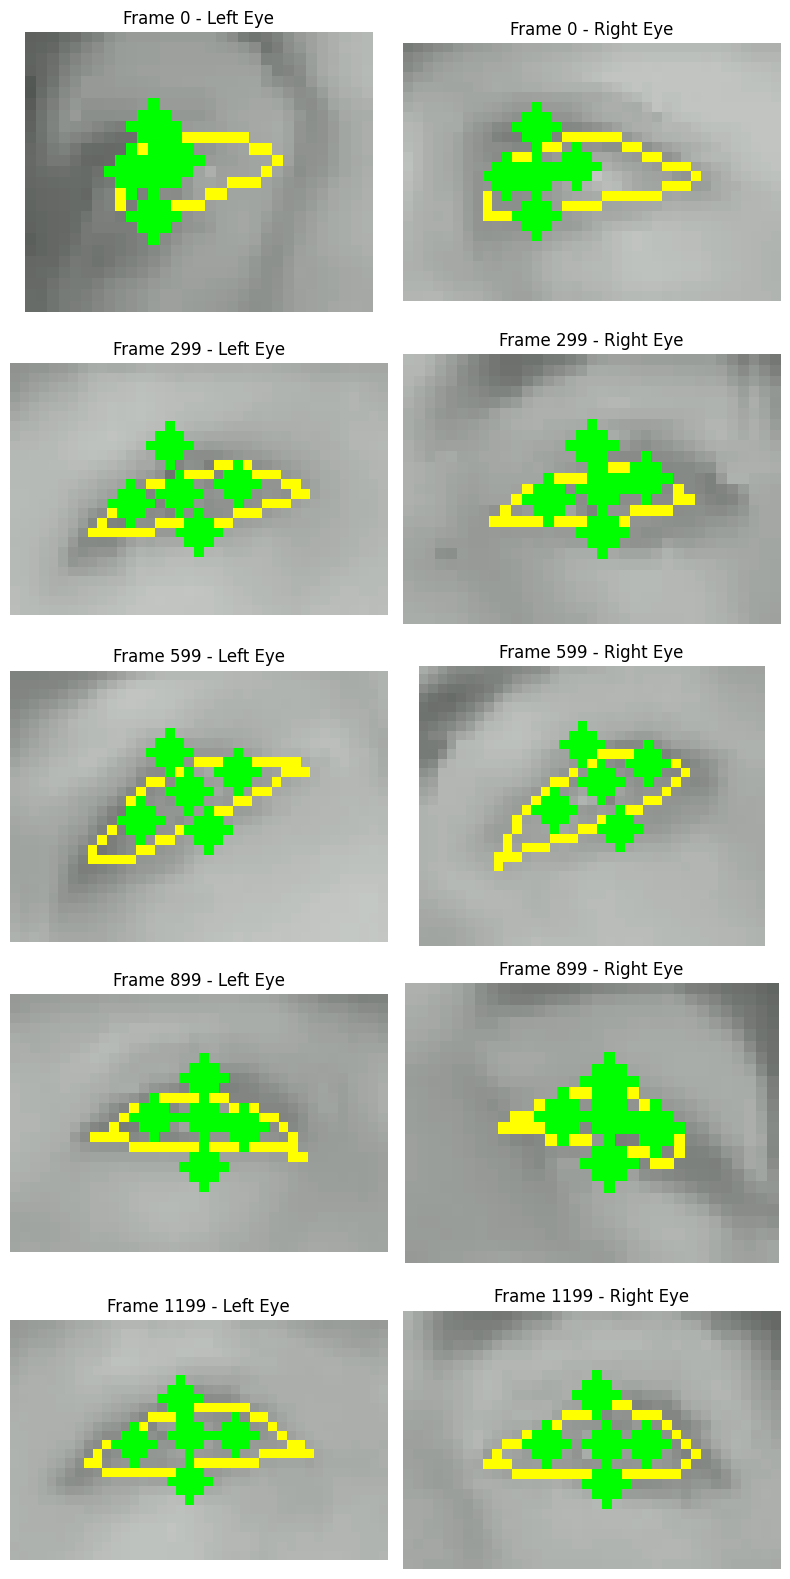

5

In [ ]:
# Explore model detections on eye crops from a few sampled frames
sample_results = show_eye_crops_with_detections(
    video_path="/Users/batakalaashok/neokpi/5642063245/8.mp4",
    sample_count=5,
    start_frame=0,
    num_faces=1,
    margin_ratio=0.28,
)

len(sample_results)

W0000 00:00:1779344573.616782 4939164 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779344573.639078 4939164 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1779344573.641620 4939170 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779344573.654778 4939170 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


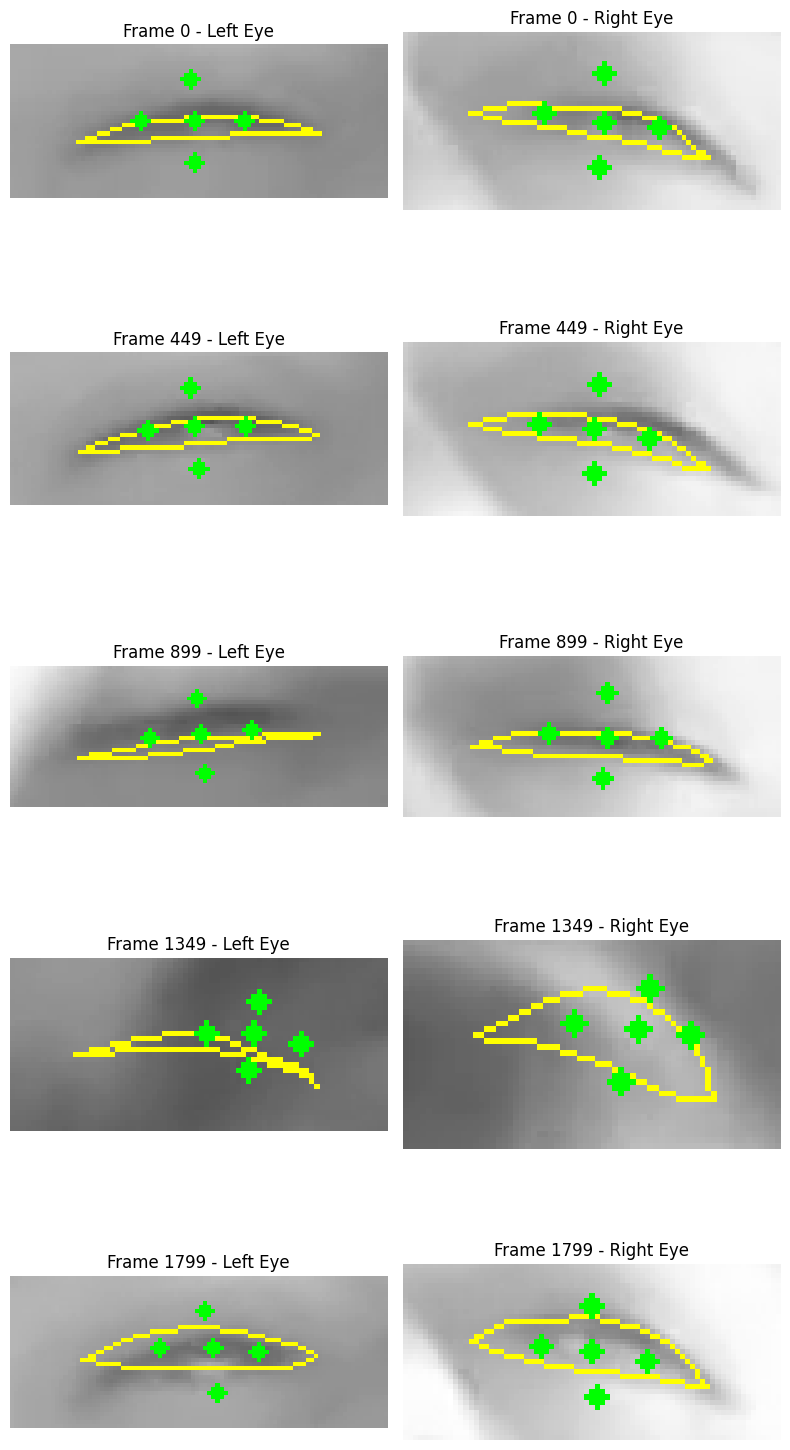

5

In [17]:
# Explore model detections on eye crops from a few sampled frames
sample_results = show_eye_crops_with_detections(
    video_path="/Users/batakalaashok/Code/mediapipe_iris/outputVideo.mp4",
    sample_count=5,
    start_frame=0,
    num_faces=1,
    margin_ratio=0.28,
)

len(sample_results)

In [24]:
# Export a video that contains only the eye crops and the landmark detections
video_path = "/Users/batakalaashok/Code/mediapipe_iris/outputVideo.mp4"
eye_output_path = "/Users/batakalaashok/Code/mediapipe_iris/outputVideo_result.mp4"

eye_summary = export_eye_crops_video(
    video_path=video_path,
    output_path=eye_output_path,
    max_frames=None,
    num_faces=1,
    margin_ratio=0.28,
    panel_size=(320, 200),
    verbose=True,
)

eye_summary

W0000 00:00:1779345046.408140 4948324 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779345046.419606 4948324 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1779345046.421991 4948329 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779345046.439243 4948329 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


{'input': '/Users/batakalaashok/Code/mediapipe_iris/outputVideo.mp4', 'output': '/Users/batakalaashok/Code/mediapipe_iris/outputVideo_result.mp4', 'frames_processed': 1800, 'frames_with_face': 1797, 'fps': 30.0, 'panel_size': (320, 200)}


{'input': '/Users/batakalaashok/Code/mediapipe_iris/outputVideo.mp4',
 'output': '/Users/batakalaashok/Code/mediapipe_iris/outputVideo_result.mp4',
 'frames_processed': 1800,
 'frames_with_face': 1797,
 'fps': 30.0,
 'panel_size': (320, 200)}

W0000 00:00:1779347510.221943 4996300 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779347510.264395 4996300 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1779347510.271629 4996305 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779347510.285121 4996305 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


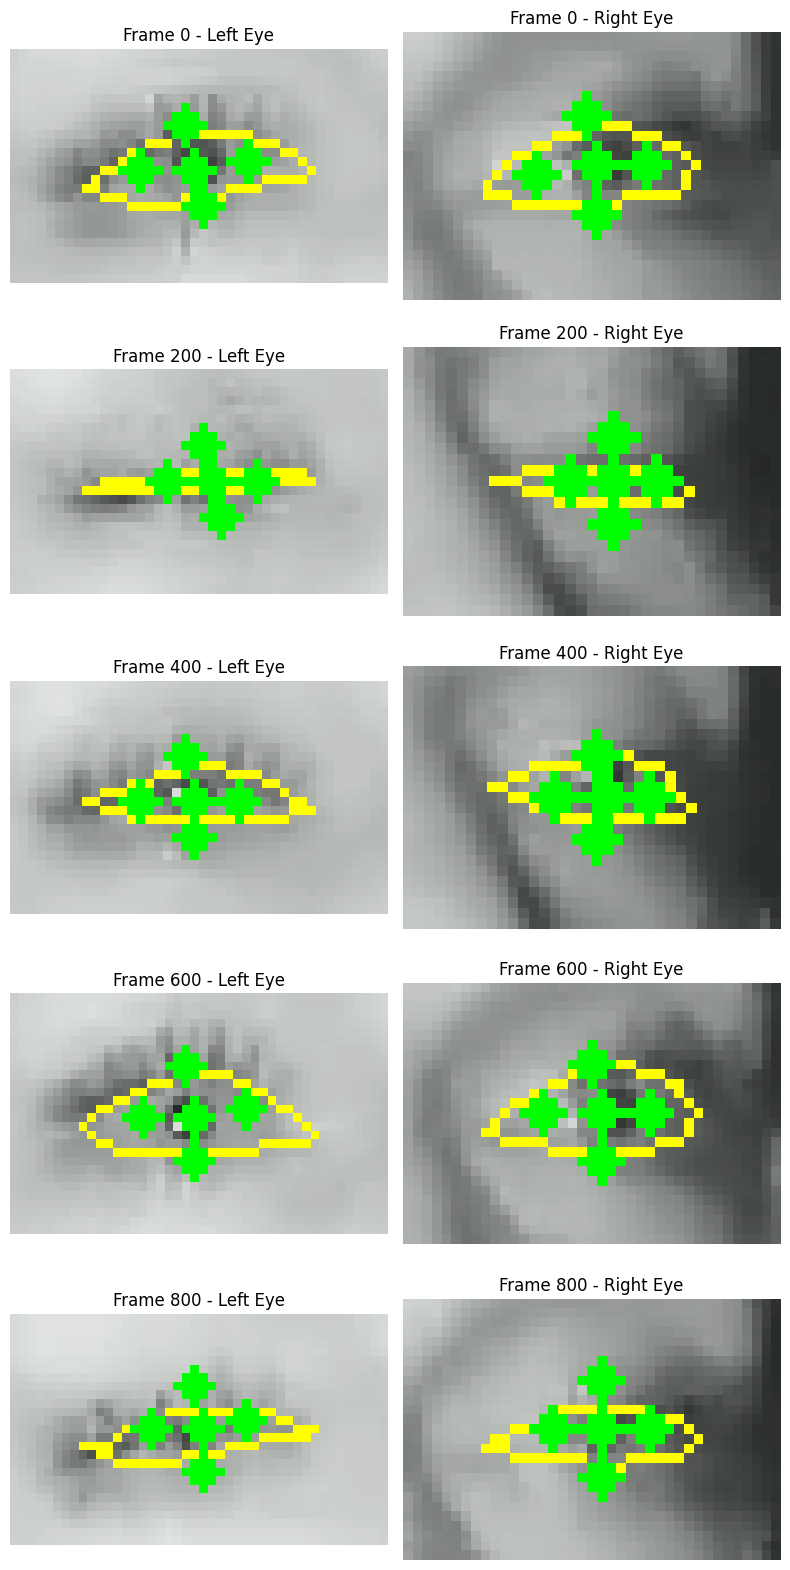

5

In [25]:
# Explore model detections on eye crops from a few sampled frames
sample_results = show_eye_crops_with_detections(
    video_path="/Users/batakalaashok/neokpi/5642063245/8.mp4",
    sample_count=5,
    start_frame=0,
    num_faces=1,
    margin_ratio=0.28,
)

len(sample_results)

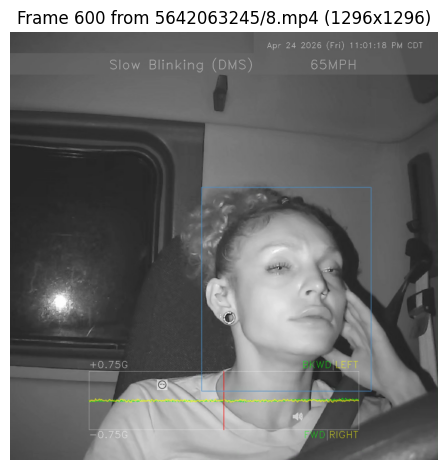

In [44]:
# Display a normal frame from the last video
cap = cv2.VideoCapture("/Users/batakalaashok/Code/mediapipe_iris/input_videos/5642063245_dms.mp4")
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
mid_frame_idx = total_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame_idx)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.title(f"Frame {mid_frame_idx} from 5642063245/8.mp4 ({frame.shape[1]}x{frame.shape[0]})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Failed to read frame")


In [35]:
frame_rgb.shape

(480, 480, 3)

W0000 00:00:1779355575.230900 5106040 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779355575.274420 5106040 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1779355575.282492 5106047 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779355575.294116 5106050 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


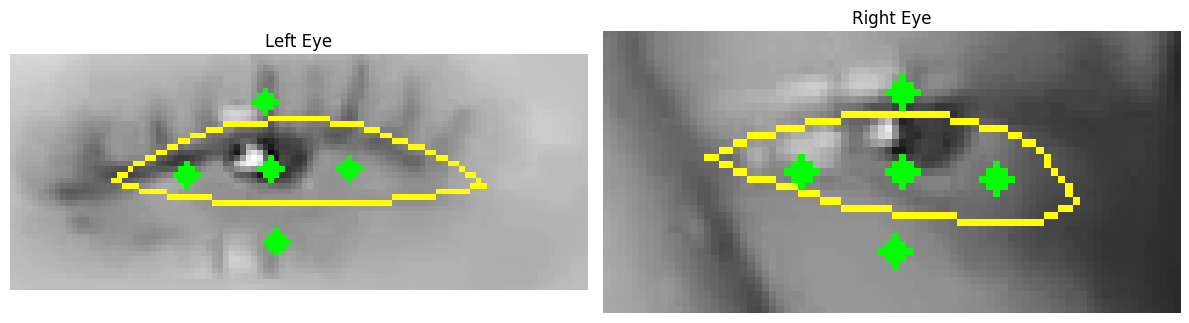

In [45]:
# Extract and plot eye crops from the current frame_rgb
frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1,
)

with FaceLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(mp_image)
    
    if result.face_landmarks:
        landmarks = result.face_landmarks[0]
        left_crop = _eye_crop_with_overlay(frame_bgr, landmarks, LEFT_EYE, LEFT_IRIS, margin_ratio=0.28)
        right_crop = _eye_crop_with_overlay(frame_bgr, landmarks, RIGHT_EYE, RIGHT_IRIS, margin_ratio=0.28)
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        if left_crop is not None:
            axes[0].imshow(left_crop)
            axes[0].set_title("Left Eye")
        else:
            axes[0].text(0.5, 0.5, "No crop", ha="center", va="center")
            axes[0].set_title("Left Eye")
        
        if right_crop is not None:
            axes[1].imshow(right_crop)
            axes[1].set_title("Right Eye")
        else:
            axes[1].text(0.5, 0.5, "No crop", ha="center", va="center")
            axes[1].set_title("Right Eye")
        
        axes[0].axis("off")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No face detected in frame")


In [42]:
def get_video_info(path, verbose=True):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {path}")

    info = {
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "total_frames": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
    }
    cap.release()

    if verbose:
        print(f"Resolution: {info['width']}×{info['height']}")
        print(f"FPS: {info['fps']}")
        print(f"Total Frames: {info['total_frames']}")
        print()

    return info


# Example usage
video_info = get_video_info("/Users/batakalaashok/neokpi/5642063245/8.mp4")
get_video_info("/Users/batakalaashok/Code/mediapipe_iris/outputVideo.mp4")
get_video_info("/Users/batakalaashok/Code/mediapipe_iris/outputVideo_result.mp4")

Resolution: 480×480
FPS: 20.0
Total Frames: 801

Resolution: 1296×1296
FPS: 30.0
Total Frames: 1800

Resolution: 656×244
FPS: 30.0
Total Frames: 1800



{'width': 656, 'height': 244, 'fps': 30.0, 'total_frames': 1800}

In [8]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 1. Download the face landmarker task bundle file from Google's official source:
# https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task
# Put it in your project directory.

model_path = 'DATA/face_landmarker.task'

# 2. Configure options and turn on iris tracking (output_face_blendshapes/output_facial_transformation_matrixes can optionally be added)
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True, 
    # The modern landmarker tracks the 478 face points (including iris) by default!
)

# 3. Create your landmarker instance
with vision.FaceLandmarker.create_from_options(options) as landmarker:
    # Load your image using MediaPipe's wrapper
    image = mp.Image.create_from_file("/Users/batakalaashok/Code/mediapipe_iris/test_face.jpg")
    detection_result = landmarker.detect(image)
    # pass

W0000 00:00:1779429616.512031 5500332 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779429616.528260 5500332 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1779429616.532326 5500334 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779429616.576079 5500334 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


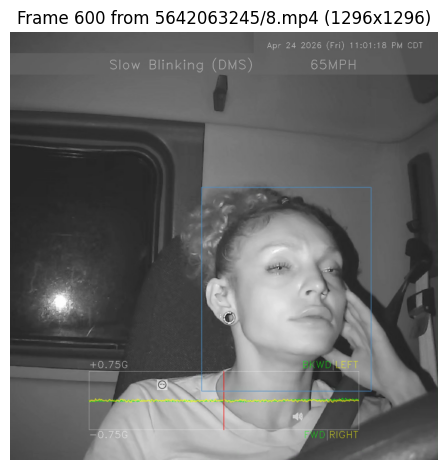

True

In [7]:
import matplotlib.pyplot as plt
# Display a normal frame from the last video
cap = cv2.VideoCapture("/Users/batakalaashok/Code/mediapipe_iris/input_videos/5642063245_dms.mp4")
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
mid_frame_idx = total_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame_idx)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # plt.figure(figsize=(12, 8))
    plt.imshow(frame_rgb)
    plt.title(f"Frame {mid_frame_idx} from 5642063245/8.mp4 ({frame.shape[1]}x{frame.shape[0]})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Failed to read frame")

# save this frame to disk for testing
cv2.imwrite("/Users/batakalaashok/Code/mediapipe_iris/test_face.jpg", frame)



In [8]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = 'DATA/face_landmarker.task'
image_path = "/Users/batakalaashok/Code/mediapipe_iris/test_face.jpg"

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=True,
)

with vision.FaceLandmarker.create_from_options(options) as landmarker:
    # 1. Load the image for MediaPipe and get results
    mp_image = mp.Image.create_from_file(image_path)
    detection_result = landmarker.detect(mp_image)
    
    # 2. Load the same image via OpenCV for drawing/plotting
    bgr_image = cv2.imread(image_path)
    h, w, _ = bgr_image.shape

    # 3. Check if any faces were detected
    if detection_result.face_landmarks:
        for face_landmarks in detection_result.face_landmarks:
            
            # Loop through all 478 landmarks
            for idx, landmark in enumerate(face_landmarks):
                # Convert normalized coordinates to pixel coordinates
                cx, cy = int(landmark.x * w), int(landmark.y * h)
                
                # Highlight Iris points (Indices 468 to 477) in Red
                if 468 <= idx <= 477:
                    cv2.circle(bgr_image, (cx, cy), 2, (0, 0, 255), -1)
                else:
                    # Draw regular face landmarks in green
                    cv2.circle(bgr_image, (cx, cy), 1, (0, 255, 0), -1)
                    
        print(f"Successfully plotted landmarks for {len(detection_result.face_landmarks)} face(s).")
    else:
        print("No faces detected in the image.")

    # 4. Display the result
    # cv2.imshow("MediaPipe Iris Detection", bgr_image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()
    
    # Optional: Save the plotted image back to disk
    cv2.imwrite("output_plotted.jpg", bgr_image)

W0000 00:00:1779431447.901998 5533635 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779431447.914453 5533635 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1779431447.915903 5533639 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779431447.963233 5533643 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Successfully plotted landmarks for 1 face(s).
